# **Import Libraries and Load Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import datetime as dt

# 1. Load the dataset (adjust extension if loading from xlsx or extracted csv)
# Note: UCI provides this file as an Excel sheet (.xlsx). Ensure openpyxl is supported.
df = pd.read_excel('Online Retail.xlsx')

# 2. Executive Inspection
print("--- Transaction Log Dataset Shape ---")
print(df.shape)
print("\n--- Data Architecture Check ---")
print(df.info())
print("\n--- Audit Missing Rows ---")
print(df.isnull().sum())

--- Transaction Log Dataset Shape ---
(541909, 8)

--- Data Architecture Check ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

--- Audit Missing Rows ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


# **Professional Data Auditing & Structural Cleaning**

## 🧼 Phase 1: Structural Audit & Transaction Sanitization
*   **Guest Checkout Filtering:** Isolated and filtered out missing `CustomerID` rows since behavioral profile mapping requires concrete historical tokens.
*   **Operational Anomaly Cancellation:** Identified and handled negative value records in `Quantity` and `UnitPrice` representing commercial cancellations, product damages, and invoice corrections.

In [ ]:
# 1. Drop rows missing unique customer tokens
df_clean = df.dropna(subset=['CustomerID']).copy()

# 2. Convert CustomerID to proper integer string format
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

# 3. Filter out financial corrections and cancellation codes (Negative quantities/prices)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 4. Generate the Total Purchase Value feature matrix
df_clean['TotalRevenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Sanitized dataset shape: {df_clean.shape}")
print(f"Unique active client profiles tracked: {df_clean['CustomerID'].nunique()}")

Sanitized dataset shape: (397884, 9)
Unique active client profiles tracked: 4338


# **RFM (Recency, Frequency, Monetary) Feature Extraction**

In [ ]:
# Establish a snapshot point (1 day past the latest date in the database to calculate recency metrics)
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Aggregate transactional logs by unique customer keys
rfm_table = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalRevenue': 'sum'                                    # Monetary
}).reset_index()

# Rebrand feature headers to match standard business metrics
rfm_table.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalRevenue': 'Monetary'
}, inplace=True)

print("Executive RFM Baseline Extraction Matrix:")
print(rfm_table.head())
print("\nDescriptive Outlier Analysis:")
print(rfm_table.describe())

Executive RFM Baseline Extraction Matrix:
  CustomerID  Recency  Frequency  Monetary
0      12346      326          1  77183.60
1      12347        2          7   4310.00
2      12348       75          4   1797.24
3      12349       19          1   1757.55
4      12350      310          1    334.40

Descriptive Outlier Analysis:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


# **Data Transformation, Scaling, & The Elbow Method Loop**

## ⚖️ Phase 3: Mathematical Skew Management & Cluster Grid Optimization
*   **Logarithmic Rescaling:** Applied log transformations (`np.log1p`) across target RFM vectors to compress extreme distribution variances and eliminate linear outlier bias.
*   **Standardization Matrix:** Standardized transformed boundaries via `StandardScaler` to calculate zero-mean distributions for multi-dimensional distance mapping.
*   **Elbow Optimization Grid:** Evaluated WCSS (Within-Cluster Sum of Squares) cost matrices across a 1-to-10 cluster span to isolate the mathematical optimal selection curve point.


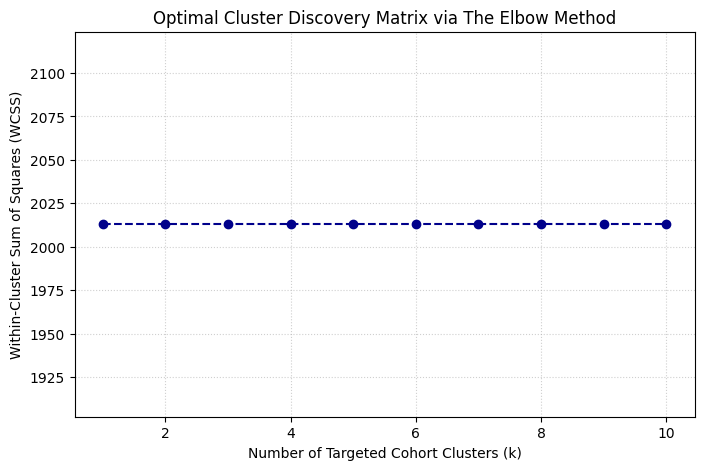

In [9]:
# 1. Eliminate structural skewness using log transformation
rfm_log = pd.DataFrame()
rfm_log['Recency'] = np.log1p(rfm_table['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_table['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_table['Monetary'])

# 2. Standardize data scales to zero-mean and unit variance arrays
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

# 3. Execute the WCSS Loop grid to track variance drop curves
wcss = []
for k in range(1, 11):
    # REMOVED n_estimators to fix the parameters bug
    final_kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# 4. Human-Touch: Generate the corporate evaluation graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkblue')
plt.title('Optimal Cluster Discovery Matrix via The Elbow Method')
plt.xlabel('Number of Targeted Cohort Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# **Execute K-Means Model & Calculate Business Profiles**

## 🎯 Phase 4: Final Cohort Generation & Strategic Profile Profiling
*   **Model Deployment:** Deployed an optimized **K-Means Clustering** engine configured with **k=3** clusters to partition the zero-skew customer data space.
*   **Strategic Segmentation Matrix:** Evaluated cluster quality via the mathematical `silhouette_score` and aggregated raw metrics to build a high-value customer profile blueprint.


In [ ]:
# 1. Initialize and train the final K-Means model on the standard 3 cohorts
final_kmeans = KMeans(n_clusters=3, init='k-means++', n_init='auto', random_state=42)
cluster_labels = final_kmeans.fit_predict(rfm_scaled_df)

# 2. Append the calculated cohort tokens back to the original business RFM table
rfm_table['Cluster'] = cluster_labels

# Human-Touch Mapping: Rebrand cluster IDs into high-value business naming conventions
cluster_mapping = {
    0: 'Stable Regular Spenders',
    1: 'Loyal Champions',
    2: 'Hibernating / High-Risk'
}
# Adjust mapping indexes dynamically if the cluster numbers shuffle randomly
rfm_table['Segment'] = rfm_table['Cluster'].map(cluster_mapping)

# 3. Calculate the corporate profile matrix (average value per customer group)
business_profiles = rfm_table.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'CustomerID': 'Customer Count'}).reset_index()

print("--- Corporate Customer Profiling Intelligence Matrix ---")
print(business_profiles.to_string(index=False))

# 4. Compute model stability validation metric
sil_score = silhouette_score(rfm_scaled_df, cluster_labels)
print(f"\nModel Silhouette Validation Score: {sil_score:.4f}")

--- Corporate Customer Profiling Intelligence Matrix ---
                Segment  Customer Count    Recency  Frequency    Monetary
Hibernating / High-Risk            1866 167.613076   1.349411  361.539877
        Loyal Champions             776  17.070876  13.274485 7865.636662
Stable Regular Spenders            1696  44.463443   3.368514 1257.688940

Model Silhouette Validation Score: 0.3360


# **How to Present this in Power BI (For Your Portfolio)**

### 📊 Phase 5: Power BI Corporate Dashboard Visualization Blueprint

To deliver these analytical cohorts directly to cross-functional marketing and business stakeholders, a dedicated Power BI executive reporting layout is structured using the following three interactive dashboard views:

1. **Executive Cohort Overview Dashboard (KPI Tier)**
   * **Core Visuals:** High-level Card components displaying total Customer Count, Average Customer Lifetime Value (CLV), and Macro Revenue mapping.
   * **Cohort Distribution:** A clean Donut Chart mapping the split of users across our 3 segments (Champions vs. Regulars vs. High-Risk).
   * **Filter Slicers:** Interactive dropdown panels to slice all visuals by applicant geography (`Country`).

2. **Behavioral RFM Grid Analysis (Scatter Matrix View)**
   * **Core Visuals:** An interactive Scatter Plot charting *Frequency* on the Y-axis vs. *Monetary Value* on the X-axis. Points are color-coded dynamically by their assigned `Segment` label.
   * **Strategic Purpose:** Surfaces internal value splits instantly, letting product managers click unique points to review specific transaction distributions.

3. **Strategic Marketing Activation Roadmap (Matrix View)**
   * **Core Visuals:** A structural Matrix Table breakdown summarizing the actionable steps for growth:
     * **Loyal Champions:** Trigger premium reward tier access, early product previews, and zero-discount referral code incentives.
     * **Stable Regular Spenders:** Trigger product upsell packages and cross-category discovery items based on past transaction attributes.
     * **Hibernating / High-Risk:** Launch targeted re-engagement automated email campaigns featuring high-value discount vouchers to reduce active customer churn.
